# Kalibrasi Skenario Hybrid NLP Tanpa LLM
Notebook ini menjadi alur presentasi. Logic utama tetap berada di folder `services/` agar mudah dipindahkan ke `main.py`.


In [1]:
from pathlib import Path
import sys

import polars as pl
from IPython.display import display


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "config.py").exists() and (candidate / "services").is_dir():
            return candidate
    raise FileNotFoundError("Root proyek tidak ditemukan")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config
from services.ambiguity_service import AmbiguityService
from services.artifact_service import ArtifactService
from services.clustering_service import ClusteringService
from services.dataset_service import DatasetService
from services.embedding_service import EmbeddingService
from services.evaluation_service import EvaluationService
from services.lexicon_sentiment_service import LexiconSentimentService
from services.preprocessing_service import PreprocessingService
from services.visualization_service import VisualizationService

pl.Config.set_tbl_hide_column_data_types(True)
pl.Config.set_tbl_cell_alignment("LEFT")
pl.Config.set_fmt_str_lengths(10_000)
pl.Config.set_tbl_width_chars(10_000)
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_rows(20)


polars.config.Config

## 1. Konfigurasi Dataset


In [2]:
DATASET_PATH = config.DATASETS / "v1_shs_datasets.csv"
OUTPUT_DATASET_PATH = config.CALIBRATION_DATASET_PATH
OUTPUT_SUMMARY_PATH = config.CALIBRATION_SUMMARY_PATH
OUTPUT_RESULTS_PATH = config.NON_LLM_RESULTS_PATH
OUTPUT_METRICS_PATH = config.NON_LLM_METRICS_PATH

RANDOM_SEED = 42
SOURCE_NAME = "tokopedia"
MAX_ROWS = 2_000  # ubah ke None jika ingin menjalankan seluruh dataset

print(f"Dataset: {DATASET_PATH}")
print(f"Batas baris demo: {MAX_ROWS if MAX_ROWS else 'semua'}")

Dataset: E:\School\tugas-akhir\project\datasets\v1_shs_datasets.csv
Batas baris demo: 2000


## 2. Load, Adaptasi Kolom, Validasi


Baris sumber: 48
Baris digunakan: 48
{'total_rows': 48, 'required_columns': ['id', 'source', 'text'], 'missing_columns': [], 'null_text': 0, 'empty_text': 0, 'empty_source': 0, 'is_valid': True, 'issues': []}


{'total_data': 48,
 'distribusi_sumber': {'tokopedia': 48},
 'jumlah_data_kosong': 0,
 'jumlah_duplikat': 0,
 'rata_rata_panjang_teks': 107.9}

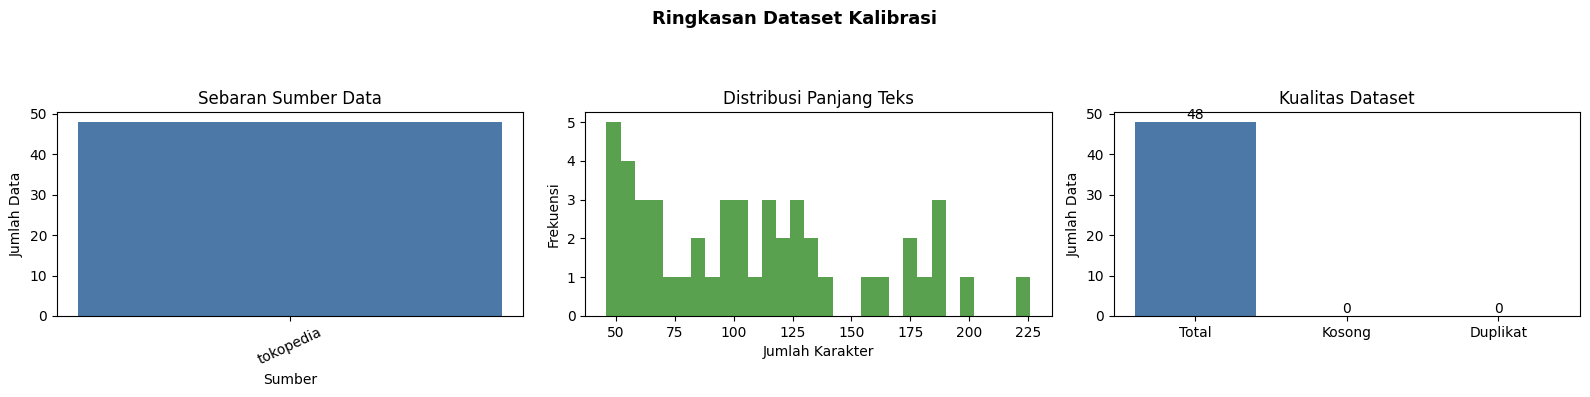

In [3]:
dataset_service = DatasetService()
evaluation_service = EvaluationService()
artifact_service = ArtifactService()
visualization_service = VisualizationService()

raw_df = dataset_service.load(DATASET_PATH)
if config.COL_TEXT not in raw_df.columns:
    raise KeyError(f"Kolom '{config.COL_TEXT}' tidak ditemukan pada dataset")

base_df = raw_df
if MAX_ROWS is not None:
    base_df = base_df.head(MAX_ROWS)

text_df = (
    base_df.select(config.COL_TEXT)
    .with_row_index(config.COL_ID, offset=1)
    .with_columns(
        pl.col(config.COL_ID).cast(pl.Utf8),
        pl.lit(SOURCE_NAME).alias(config.COL_SOURCE),
        pl.col(config.COL_TEXT).cast(pl.Utf8, strict=False),
    )
    .select(
        config.COL_ID,
        config.COL_SOURCE,
        config.COL_TEXT,
    )
)

validation = dataset_service.validate(text_df)
summary = dataset_service.build_summary(text_df)

print(f"Baris sumber: {raw_df.height:,}")
print(f"Baris digunakan: {text_df.height:,}")
print(validation)
display(summary)
fig_dataset = visualization_service.plot_dataset_overview(text_df, summary)

## 3. Cleaning, Deduplikasi, dan Preprocessing


Baris setelah preprocessing: 48


id,text,processed_text
"""1""","""Sejak 2023 sudah ada wacana listrik 24 jam menggunakan panel surya energi baru terbarukan, tetapi hingga kini belum terealisasi.""","""sejak 2023 sudah ada wacana listrik 24 jam menggunakan panel surya energi baru terbarukan, tetapi hingga kini belum terealisasi."""
"""2""","""Nopriandi berharap Bupati Bengkayang dan Gubernur Kalimantan Barat memperjuangkan agar listrik di Pulau Lemukutan dapat menyala 24 jam.""","""nopriandi berharap bupati bengkayang dan gubernur kalimantan barat memperjuangkan agar listrik di pulau lemukutan dapat menyala 24 jam."""
"""3""","""Hunin Herdanus, Pengurus Gereja Katolik Santo Kristoforus, menyambut positif bantuan PLTS tersebut.""","""hunin herdanus, pengurus gereja katolik santo kristoforus, menyambut positif bantuan pembangkit listrik tenaga surya tersebut."""
"""4""","""Biaya listrik selama ini menjadi salah satu pengeluaran rutin gereja yang cukup besar.""","""biaya listrik selama ini menjadi salah satu pengeluaran rutin gereja yang cukup besar."""
"""5""","""Kehadiran PLTS atap akan sangat membantu efisiensi pengeluaran operasional harian.""","""kehadiran pembangkit listrik tenaga surya atap akan sangat membantu efisiensi pengeluaran operasional harian."""
"""6""","""Pengurangan pembayaran listrik dirasakan mencapai 30–40%.""","""pengurangan pembayaran listrik dirasakan mencapai 30 40 ."""
"""7""","""Perbedaan tagihan listriknya mencapai 50% pada daya yang sama.""","""perbedaan tagihan listriknya mencapai 50 pada daya yang sama."""
"""8""","""Menurut Ferdi, investasi tersebut bukan suatu kerugian.""","""menurut ferdi, investasi tersebut bukan suatu kerugian."""
"""9""","""Ferdi berhasil memiliki rumah yang hemat energi.""","""ferdi berhasil memiliki rumah yang hemat energi."""
"""10""","""Ferdi tidak lagi khawatir terhadap pemadaman listrik bergilir.""","""ferdi tidak lagi khawatir terhadap pemadaman listrik bergilir."""


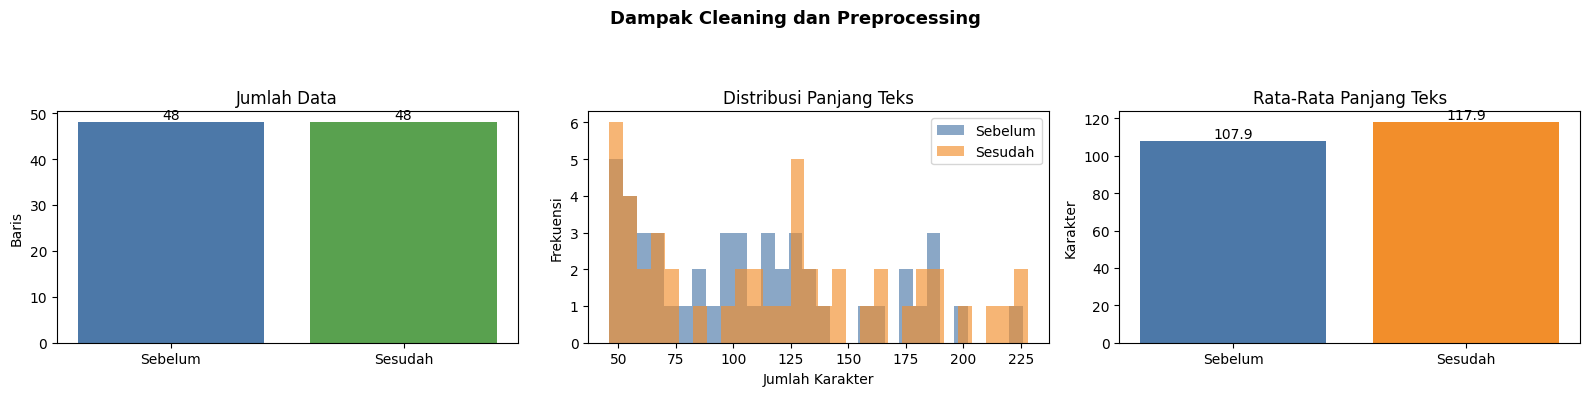

In [4]:
preprocessing_service = PreprocessingService()

clean_df = text_df.filter(
    pl.col(config.COL_TEXT).is_not_null()
    & (pl.col(config.COL_TEXT).str.strip_chars().str.len_chars() > 0)
)

clean_df = dataset_service.deduplicate(clean_df)

processed_df = preprocessing_service.process_dataframe(clean_df).filter(
    pl.col(config.COL_PROCESSED).is_not_null()
    & (pl.col(config.COL_PROCESSED).str.strip_chars().str.len_chars() > 0)
)

processed_summary = dataset_service.build_summary(processed_df)

artifact_service.save_dataframe(
    processed_df,
    OUTPUT_DATASET_PATH,
)
dataset_service.export_summary(
    processed_summary,
    OUTPUT_SUMMARY_PATH,
)

print(f"Baris setelah preprocessing: {processed_df.height:,}")

display(
    processed_df.select(
        config.COL_ID,
        config.COL_TEXT,
        config.COL_PROCESSED,
    ).head(20)
)

fig_preprocessing = visualization_service.plot_preprocessing_overview(
    text_df,
    processed_df,
)

## 4. Rule-Based Sentiment


id,processed_text,rule_label,rule_score,rule_confidence,rule_hits
"""1""","""sejak 2023 sudah ada wacana listrik 24 jam menggunakan panel surya energi baru terbarukan, tetapi hingga kini belum terealisasi.""","""netral""",0.0,0.0,"""panel surya"""
"""2""","""nopriandi berharap bupati bengkayang dan gubernur kalimantan barat memperjuangkan agar listrik di pulau lemukutan dapat menyala 24 jam.""","""netral""",0.0,0.0,""""""
"""3""","""hunin herdanus, pengurus gereja katolik santo kristoforus, menyambut positif bantuan pembangkit listrik tenaga surya tersebut.""","""netral""",0.0,0.0,""""""
"""4""","""biaya listrik selama ini menjadi salah satu pengeluaran rutin gereja yang cukup besar.""","""negatif""",-1.0,1.0,"""salah"""
"""5""","""kehadiran pembangkit listrik tenaga surya atap akan sangat membantu efisiensi pengeluaran operasional harian.""","""positif""",2.0,1.0,"""sangat membantu"""
"""6""","""pengurangan pembayaran listrik dirasakan mencapai 30 40 .""","""netral""",0.0,0.0,""""""
"""7""","""perbedaan tagihan listriknya mencapai 50 pada daya yang sama.""","""netral""",0.0,0.0,""""""
"""8""","""menurut ferdi, investasi tersebut bukan suatu kerugian.""","""netral""",0.0,0.0,""""""
"""9""","""ferdi berhasil memiliki rumah yang hemat energi.""","""positif""",1.3,1.0,"""hemat"""
"""10""","""ferdi tidak lagi khawatir terhadap pemadaman listrik bergilir.""","""netral""",0.0,0.0,""""""


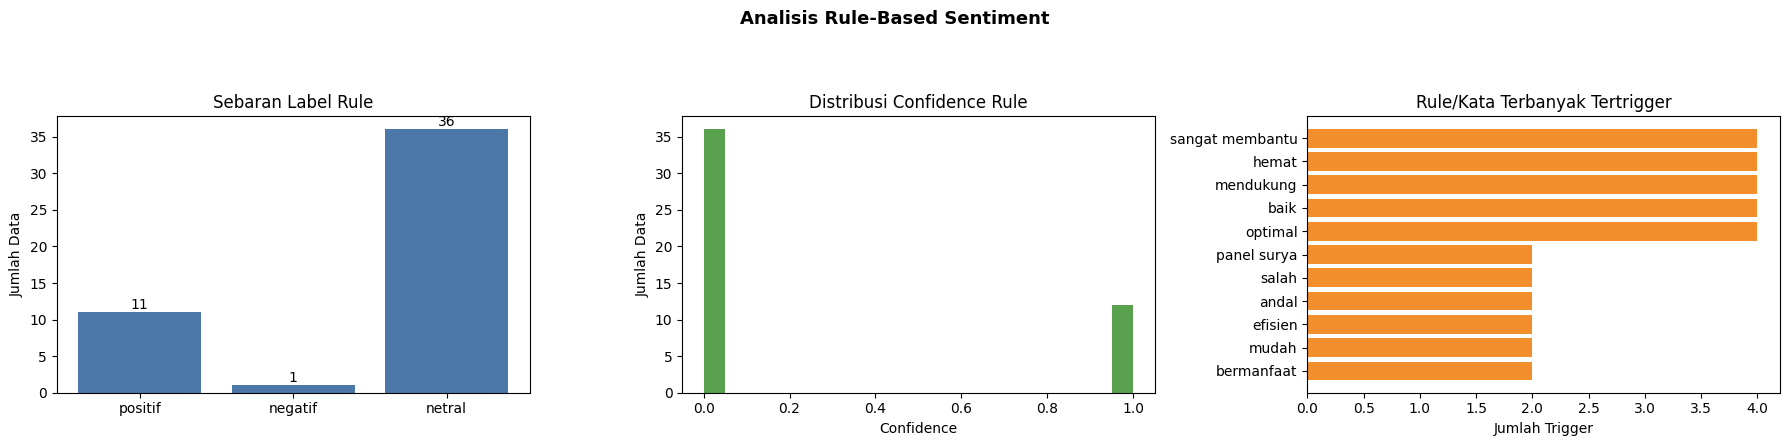

In [5]:
lexicon_service = LexiconSentimentService()
rule_df = lexicon_service.analyze_dataframe(processed_df)

rule_preview = rule_df.select(
    config.COL_ID,
    config.COL_PROCESSED,
    config.COL_RULE_LABEL,
    "rule_score",
    config.COL_RULE_CONFIDENCE,
    "rule_hits",
)
display(rule_preview.head(25))
fig_rule = visualization_service.plot_rule_sentiment_overview(rule_df)


## 5. Embedding dan Clustering Semantic


## 6. Ambiguity Detection Tanpa LLM


## 7. Evaluasi Skenario Tanpa LLM


## 8. Visualisasi Evaluasi Detail


## 9. Ringkasan Distribusi
